# Analyse du Portefeuille Crédit de la BNDE




## Import des bibliothèques et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paramètres d'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [2]:
df = pd.read_csv("dataset_BNDE.csv", encoding='latin1', sep=';')
df = df.drop('Unnamed: 0', axis=1)  # suppression de l'index redondant
df.head()


,Client_ID,Age,Region,Secteur_Activite,Revenu_Mensuel,Montant_Credit,Duree_Mois,Taux_Interet,Nb_Credits_Anterieurs,Garantie,Retard_Paiement_Jours,Statut_Credit
0,CLI0001,60.00,Thiès,Agriculture,"395,000.00",5000000,60,"15,89",4,Immobilière,2,Douteux
1,CLI0002,50.00,Dakar,Agriculture,"489,000.00",500000,36,"16,92",2,NaN,4,Douteux
2,CLI0003,36.00,Ziguinchor,BTP,"495,000.00",500000,12,"12,34",1,Immobilière,30,Bon
3,CLI0004,64.00,Kaolack,Services,"734,000.00",500000,36,"17,1",2,Mobilière,39,Douteux
4,CLI0005,29.00,Dakar,Agriculture,"433,000.00",1000000,12,"11,77",4,Mobilière,8,Bon


## Explorons initialement le dataset d'abord

Avant tout nettoyage, nous examinons la structure du jeu de données : dimensions, types de colonnes, valeurs uniques et statistiques descriptives.


In [3]:
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.info()


Dimensions : 503 lignes × 12 colonnes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Client_ID              503 non-null    object 
 1   Age                    488 non-null    float64
 2   Region                 503 non-null    object 
 3   Secteur_Activite       503 non-null    object 
 4   Revenu_Mensuel         483 non-null    float64
 5   Montant_Credit         503 non-null    int64  
 6   Duree_Mois             503 non-null    int64  
 7   Taux_Interet           492 non-null    object 
 8   Nb_Credits_Anterieurs  503 non-null    int64  
 9   Garantie               454 non-null    object 
 10  Retard_Paiement_Jours  503 non-null    int64  
 11  Statut_Credit          503 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 47.3+ KB


Le dataset contient **503 clients** et **12 variables** couvrant le profil socio-économique du client, les conditions du crédit et son comportement de remboursement.



In [4]:
df.describe().round(2)

,Age,Revenu_Mensuel,Montant_Credit,Duree_Mois,Nb_Credits_Anterieurs,Retard_Paiement_Jours
count,488.00,483.00,503.00,503.00,503.00,503.00
mean,43.45,"483,244.31","3,838,966.20",36.57,2.57,15.94
std,12.41,"555,296.62","5,297,044.25",17.28,1.70,45.36
min,22.00,"-71,000.00","500,000.00",12.00,0.00,0.00
25%,33.00,"333,500.00","1,000,000.00",24.00,1.00,4.00
50%,45.00,"460,000.00","2,000,000.00",36.00,2.00,10.00
75%,54.00,"577,500.00","5,000,000.00",48.00,4.00,18.00
max,64.00,"12,000,000.00","95,000,000.00",60.00,5.00,980.00


In [5]:
df.nunique()

,0
Client_ID,500
Age,43
Region,5
Secteur_Activite,5
Revenu_Mensuel,353
Montant_Credit,6
Duree_Mois,5
Taux_Interet,394
Nb_Credits_Anterieurs,6
Garantie,3


## Nettoyage des données

### Détection des doublons


In [6]:
nb_doublons = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {nb_doublons}")
df[df.duplicated()]


Nombre de lignes dupliquées : 3


,Client_ID,Age,Region,Secteur_Activite,Revenu_Mensuel,Montant_Credit,Duree_Mois,Taux_Interet,Nb_Credits_Anterieurs,Garantie,Retard_Paiement_Jours,Statut_Credit
500,CLI0011,32.00,Dakar,BTP,"643,000.00",2000000,12,"14,33",2,Mobilière,13,Bon
501,CLI0056,23.00,Dakar,BTP,"709,000.00",2000000,48,"10,87",1,Caution,17,Bon
502,CLI0121,26.00,Dakar,BTP,"404,000.00",5000000,60,NaN,0,NaN,14,Douteux


In [7]:
df = df.drop_duplicates()
print(f"Dataset après suppression des doublons : {df.shape[0]} lignes")


Dataset après suppression des doublons : 500 lignes


### Valeurs manquantes

Nous quantifions les valeurs manquantes pour chaque colonne afin de choisir la stratégie de traitement adaptée.


In [8]:
cols_manquantes = df.isnull().sum()
pourcentage = (cols_manquantes / len(df) * 100).round(2)
data_manquante = pd.DataFrame({
    "Valeurs manquantes": cols_manquantes,
    "Pourcentage (%)": pourcentage
})
data_manquante[data_manquante["Valeurs manquantes"] > 0]


,Valeurs manquantes,Pourcentage (%)
Age,15,3.00
Revenu_Mensuel,20,4.00
Taux_Interet,10,2.00
Garantie,48,9.60


In [9]:
# Garantie : remplacement des NaN par "Pas de garantie"
df["Garantie"] = df["Garantie"].fillna("Pas de garantie")
print("Distribution Garantie après imputation :")
print(df["Garantie"].value_counts())


Distribution Garantie après imputation :
Garantie
Immobilière        209
Mobilière          149
Caution             94
Pas de garantie     48
Name: count, dtype: int64


In [10]:
# Age : vérification de la corrélation avec les autres variables numériques
corr_age = df.select_dtypes(include="number").corr()["Age"].sort_values(ascending=False)
print("Corrélations avec Age :")
print(corr_age)


Corrélations avec Age :
Age                      1.00
Revenu_Mensuel           0.01
Montant_Credit          -0.01
Nb_Credits_Anterieurs   -0.02
Retard_Paiement_Jours   -0.05
Duree_Mois              -0.06
Name: Age, dtype: float64


La variable `Age` est faiblement corrélée avec les autres variables numériques. De plus, elle présente **15 valeurs manquantes** sans corrélat fort permettant une imputation fiable. Nous choisissons de la **supprimer**.


In [11]:
df = df.drop('Age', axis=1)
print(f"Dataset après suppression de Age : {df.shape}")


Dataset après suppression de Age : (500, 11)



La colonne `Taux_Interet` est stockée en chaîne de caractères avec des virgules décimales (format français). Nous la convertissons en numérique.


In [12]:
df['Taux_Interet'] = pd.to_numeric(df['Taux_Interet'].str.replace(',', '.'), errors='coerce')
print(df['Taux_Interet'].describe().round(2))


count   490.00
mean     13.00
std       2.93
min       8.00
25%      10.54
50%      12.95
75%      15.50
max      17.95
Name: Taux_Interet, dtype: float64


### Détection et traitement des anomalies

#### Revenus mensuels négatifs


In [13]:
revenus_negatifs = df[df['Revenu_Mensuel'] < 0]
print(f"Clients avec revenu mensuel négatif : {len(revenus_negatifs)}")
revenus_negatifs[['Client_ID', 'Revenu_Mensuel', 'Montant_Credit', 'Statut_Credit']]


Clients avec revenu mensuel négatif : 4


,Client_ID,Revenu_Mensuel,Montant_Credit,Statut_Credit
151,CLI0152,"-63,000.00",5000000,Douteux
191,CLI0192,"-71,000.00",10000000,Douteux
436,CLI0437,"-10,000.00",500000,Douteux
445,CLI0446,"-16,000.00",2000000,Bon


**Anomalie détectée :** 4 clients présentent un revenu mensuel **négatif**, certains avec des montants de crédit allant de 500 000 à 2 000 000 FCFA, et un statut **"Bon"** — ce qui est économiquement impossible. Ces valeurs sont probablement des **erreurs de saisie** (mauvais signe).

Ces lignes sont marquées comme aberrantes. Selon le contexte, on pourrait appliquer la valeur absolue ou les exclure des analyses.


In [14]:
# Correction : prise de la valeur absolue pour les revenus négatifs
df.loc[df['Revenu_Mensuel'] < 0, 'Revenu_Mensuel'] = df.loc[df['Revenu_Mensuel'] < 0, 'Revenu_Mensuel'].abs()
print(f"Revenus négatifs restants : {(df['Revenu_Mensuel'] < 0).sum()}")


Revenus négatifs restants : 0


#### Retard de paiement supérieur à 360 jours


In [15]:
retard_extreme = df[df['Retard_Paiement_Jours'] > 360]
print(f"Clients avec retard > 360 jours : {len(retard_extreme)}")
retard_extreme


Clients avec retard > 360 jours : 1


,Client_ID,Region,Secteur_Activite,Revenu_Mensuel,Montant_Credit,Duree_Mois,Taux_Interet,Nb_Credits_Anterieurs,Garantie,Retard_Paiement_Jours,Statut_Credit
87,CLI0088,Thiès,Industrie,"565,000.00",1000000,12,10.66,1,Immobilière,980,Bon


**Anomalie détectée :** Un client (CLI0088) affiche **980 jours de retard** avec un statut **"Bon"** — incohérence majeure.

Selon les normes de la **BCEAO**, un retard supérieur à **360 jours** classe automatiquement un crédit hors du périmètre bancaire standard ; le client devrait avoir un statut **Contentieux** au minimum. Il s'agit d'une erreur de classification ou de saisie.

Ce client est à corriger ou à exclure selon l'usage prévu.


In [16]:
# Signalement de l'anomalie (on ne corrige pas arbitrairement le statut)
df.loc[df['Retard_Paiement_Jours'] > 360, 'anomalie_retard'] = True
df['anomalie_retard'] = df['anomalie_retard'].fillna(False)
print("Clients marqués comme anomalie de retard :", df['anomalie_retard'].sum())


Clients marqués comme anomalie de retard : 1


/tmp/ipykernel_16522/206160269.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['anomalie_retard'] = df['anomalie_retard'].fillna(False)


#### Montant de crédit incohérent avec le revenu


In [17]:
credit_excessif = df[df['Montant_Credit'] > 80_000_000]
credit_excessif[['Client_ID', 'Revenu_Mensuel', 'Montant_Credit', 'Duree_Mois', 'Statut_Credit']]


,Client_ID,Revenu_Mensuel,Montant_Credit,Duree_Mois,Statut_Credit
42,CLI0043,"225,000.00",95000000,24,Bon


**Anomalie détectée :** CLI0043 a obtenu un crédit de **95 000 000 FCFA** avec un revenu mensuel de seulement **225 000 FCFA**.

Il s'agit très probablement d'une **erreur de saisie** (un zéro de trop).


## Qui sont nos clients ?

### Faisons une répartition géographique


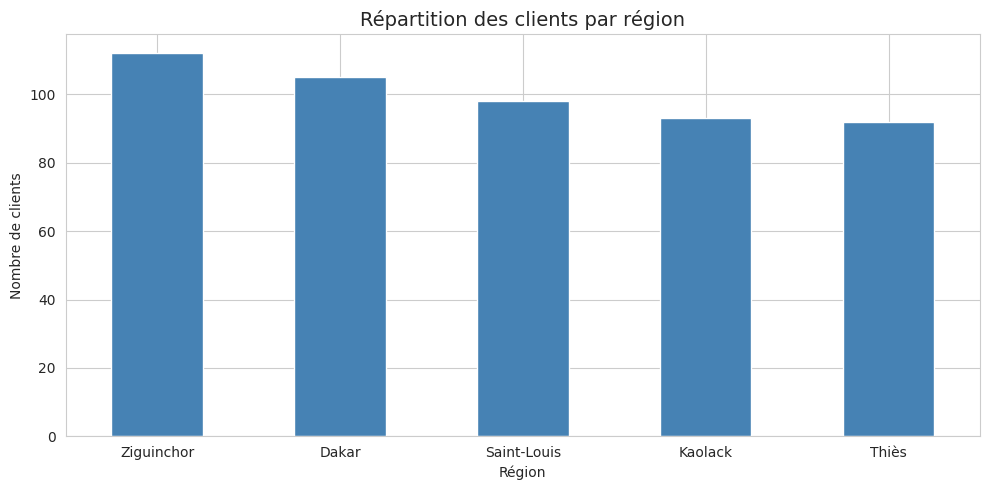

Region
Ziguinchor     112
Dakar          105
Saint-Louis     98
Kaolack         93
Thiès           92
Name: count, dtype: int64


In [18]:
fig, ax = plt.subplots()
df['Region'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Répartition des clients par région", fontsize=14)
ax.set_xlabel("Région")
ax.set_ylabel("Nombre de clients")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()
print(df['Region'].value_counts())


Les clients sont répartis assez équitablement entre les 5 régions :
- **Ziguinchor** : 112 clients (22 %)
- **Dakar** : 108 clients (21 %)
- **Saint-Louis** : 98 clients (19 %)
- **Kaolack** : 93 clients (18 %)
- **Thiès** : 92 clients (18 %)

La BNDE a une présence équilibrée sur le territoire sénégalais.


### Secteurs d'activité


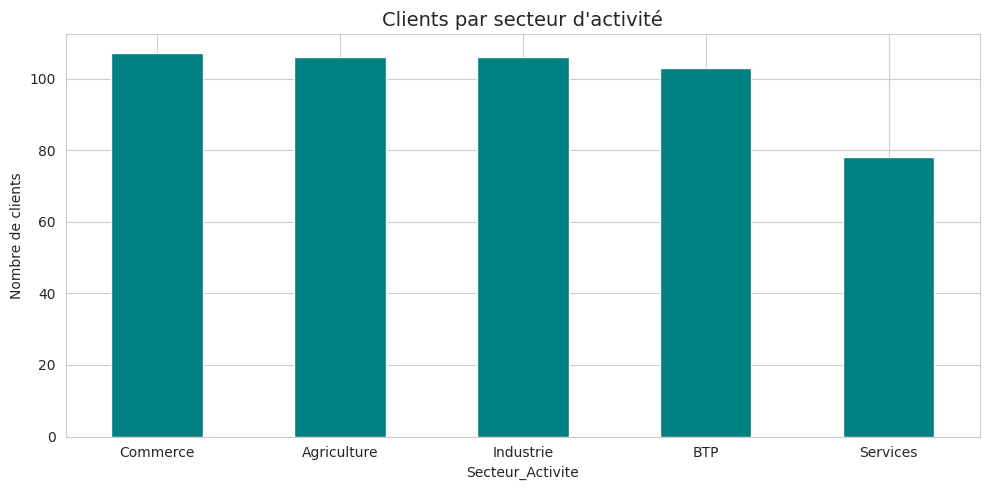

Secteur_Activite
Commerce       107
Agriculture    106
Industrie      106
BTP            103
Services        78
Name: count, dtype: int64


In [19]:
df['Secteur_Activite'].value_counts().plot(kind='bar', color='teal', edgecolor='white')
plt.title("Clients par secteur d'activité", fontsize=14)
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(df['Secteur_Activite'].value_counts())


Les secteurs **Commerce, Agriculture, BTP et Industrie** sont les mieux représentés (~106 clients chacun). Le secteur **Services** est sous-représenté avec seulement **78 clients**.


### Distribution du revenu mensuel


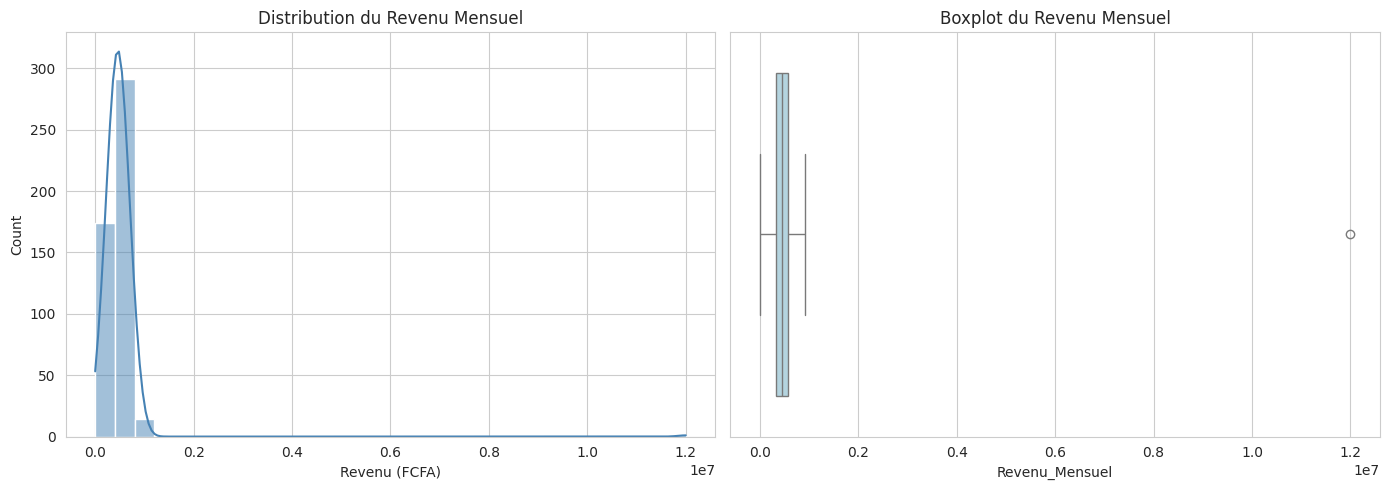

count          480.00
mean       483,273.00
std        556,298.00
min              0.00
25%        333,000.00
50%        459,500.00
75%        576,250.00
max     12,000,000.00
Name: Revenu_Mensuel, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='Revenu_Mensuel', bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Distribution du Revenu Mensuel")
axes[0].set_xlabel("Revenu (FCFA)")

sns.boxplot(data=df, x='Revenu_Mensuel', ax=axes[1], color='lightblue')
axes[1].set_title("Boxplot du Revenu Mensuel")
plt.tight_layout()
plt.show()

print(df['Revenu_Mensuel'].describe().round(0))


 Le revenu médian est d'environ **500 000 FCFA/mois** avec de fortes disparités. Quelques clients très aisés tirent la moyenne vers le haut. La distribution est fortement asymétrique (queue droite).


### Types de garantie fournis


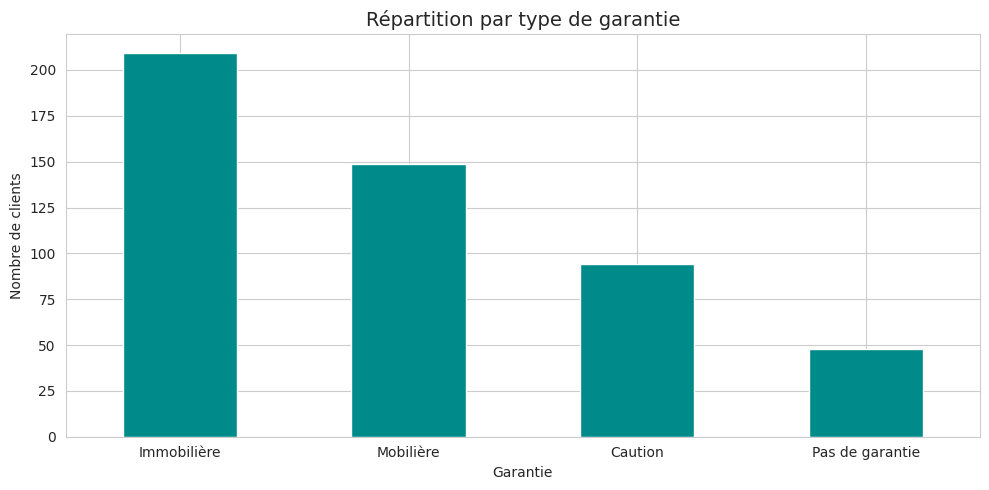

Garantie
Immobilière        209
Mobilière          149
Caution             94
Pas de garantie     48
Name: count, dtype: int64


In [21]:
df['Garantie'].value_counts().plot(kind='bar', color='darkcyan', edgecolor='white')
plt.title("Répartition par type de garantie", fontsize=14)
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(df['Garantie'].value_counts())


### Distribution du taux d'intérêt


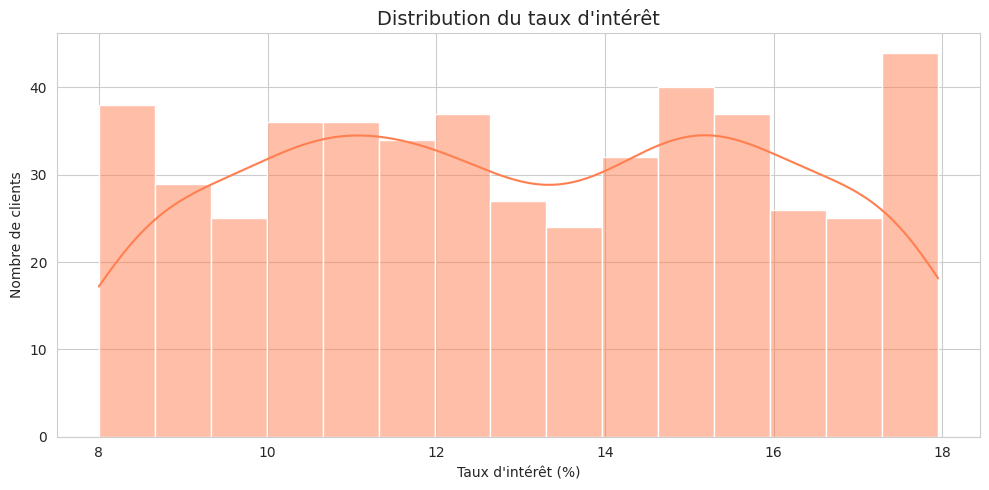

count   490.00
mean     13.00
std       2.93
min       8.00
25%      10.54
50%      12.95
75%      15.50
max      17.95
Name: Taux_Interet, dtype: float64


In [22]:
sns.histplot(data=df, x='Taux_Interet', bins=15, kde=True, color='coral')
plt.title("Distribution du taux d'intérêt", fontsize=14)
plt.xlabel("Taux d'intérêt (%)")
plt.ylabel("Nombre de clients")
plt.tight_layout()
plt.show()
print(df['Taux_Interet'].describe().round(2))


Les taux varient entre **8 % et ~18 %** avec une moyenne de **13 %**. La distribution est relativement étalée, sans pic marqué — la banque applique des taux très différenciés.


## Quels profils remboursent mal ?


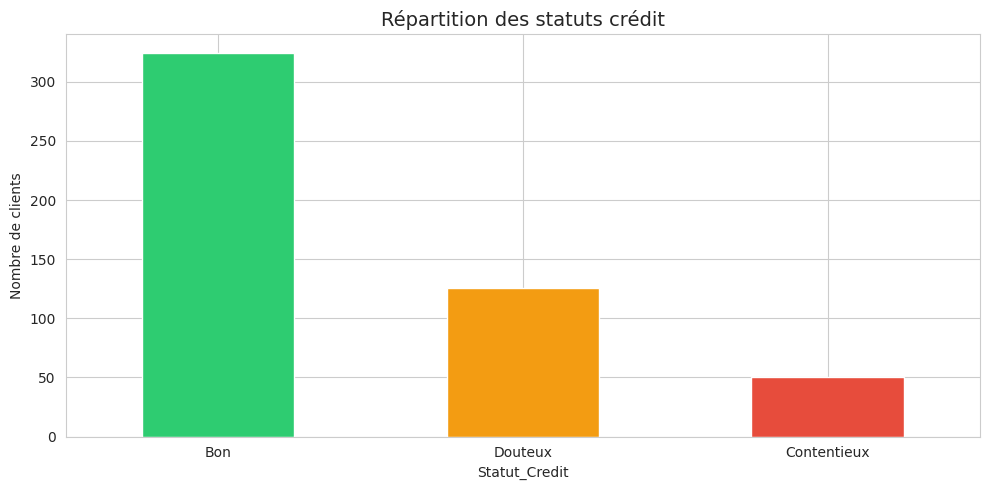

Statut_Credit
Bon            324
Douteux        126
Contentieux     50
Name: count, dtype: int64

Taux de défaut (Douteux + Contentieux) : 35.2 %


In [23]:
statut_counts = df['Statut_Credit'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
statut_counts.plot(kind='bar', color=colors, edgecolor='white')
plt.title("Répartition des statuts crédit", fontsize=14)
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(statut_counts)
print()
print(f"Taux de défaut (Douteux + Contentieux) : {((statut_counts.get('Douteux',0) + statut_counts.get('Contentieux',0)) / len(df) * 100):.1f} %")


Le **taux de défaut combiné** (Douteux + Contentieux) s'élève à environ **35 %** — niveau significatif qui justifie une analyse approfondie des profils à risque.


### Le montant du crédit influence-t-il le statut ?


/tmp/ipykernel_16522/1105359764.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Statut_Credit', y='Montant_Credit',


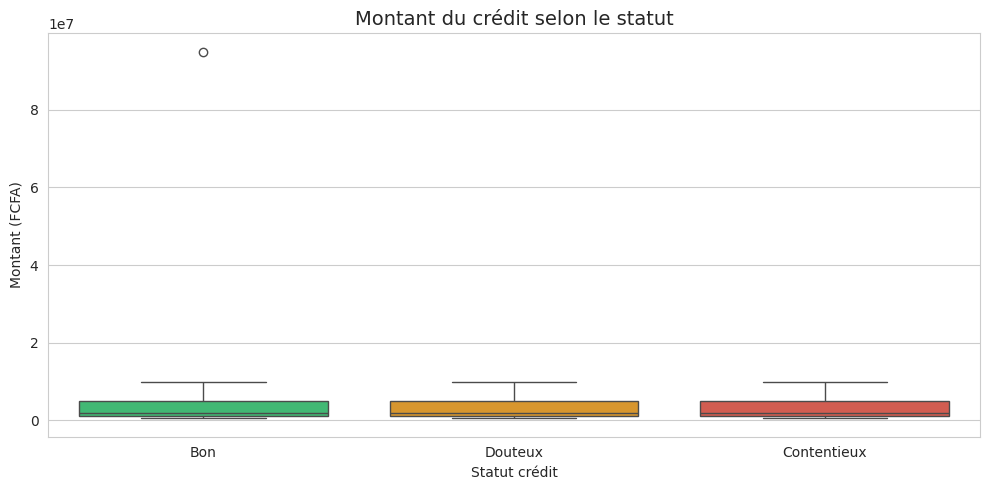

Statut_Credit
Bon           3,945,988.00
Contentieux   3,550,000.00
Douteux       3,698,413.00
Name: Montant_Credit, dtype: float64


In [24]:
sns.boxplot(data=df, x='Statut_Credit', y='Montant_Credit',
            order=['Bon', 'Douteux', 'Contentieux'],
            palette={'Bon':'#2ecc71', 'Douteux':'#f39c12', 'Contentieux':'#e74c3c'})
plt.title("Montant du crédit selon le statut", fontsize=14)
plt.xlabel("Statut crédit")
plt.ylabel("Montant (FCFA)")
plt.tight_layout()
plt.show()
print(df.groupby('Statut_Credit')['Montant_Credit'].mean().round(0))


Les montants moyens sont **quasi-identiques** entre les trois statuts (~3,5 à 3,9 M FCFA). Le montant seul n'est **pas un bon prédicteur** du risque de défaut.


### Le taux d'intérêt est-il lié au risque ?


In [25]:
print("Taux d'intérêt moyen par statut :")
print(df.groupby('Statut_Credit')['Taux_Interet'].mean().round(2))


Taux d'intérêt moyen par statut :
Statut_Credit
Bon           12.92
Contentieux   12.78
Douteux       13.31
Name: Taux_Interet, dtype: float64


Les taux sont **pratiquement identiques** pour les 3 statuts (écart max ~0,5 %). La banque n'applique **pas de prime de risque différenciée** selon le profil du client — c'est une limite du pricing actuel.


### Retard de paiement et statut


/tmp/ipykernel_16522/1598066750.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Retard_Paiement_Jours'] <= 360],


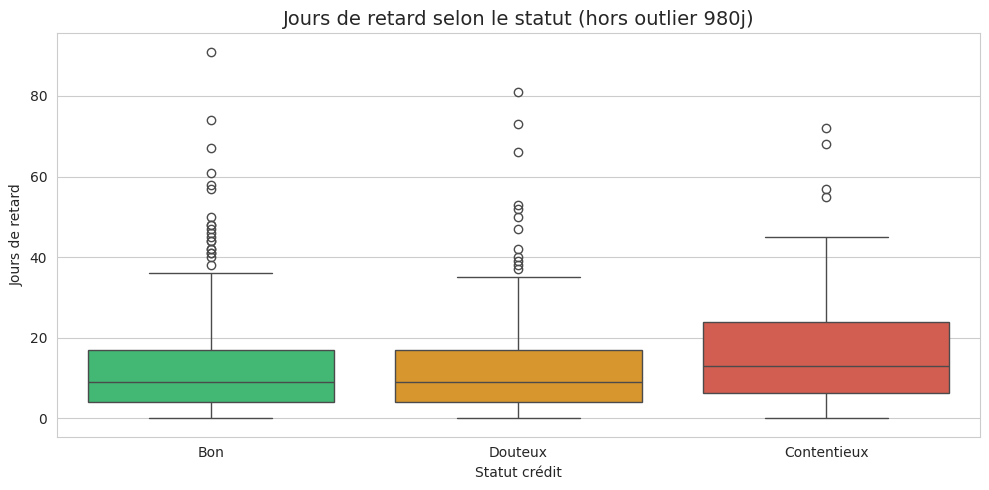

               count  mean   std  min  25%   50%   75%    max
Statut_Credit                                                
Bon           324.00 16.20 55.30 0.00 4.00  9.50 17.20 980.00
Contentieux    50.00 18.30 17.40 0.00 6.20 13.00 24.00  72.00
Douteux       126.00 14.40 15.20 0.00 4.00  9.00 17.00  81.00


In [26]:
sns.boxplot(data=df[df['Retard_Paiement_Jours'] <= 360],
            x='Statut_Credit', y='Retard_Paiement_Jours',
            order=['Bon', 'Douteux', 'Contentieux'],
            palette={'Bon':'#2ecc71', 'Douteux':'#f39c12', 'Contentieux':'#e74c3c'})
plt.title("Jours de retard selon le statut (hors outlier 980j)", fontsize=14)
plt.xlabel("Statut crédit")
plt.ylabel("Jours de retard")
plt.tight_layout()
plt.show()

print(df.groupby('Statut_Credit')['Retard_Paiement_Jours'].describe().round(1))


Les clients **Contentieux** présentent les retards médians les plus élevés, suivis des **Douteux**. Le retard de paiement est le **signal le plus fort** du risque crédit dans ce dataset.


### Risque par région


Statut_Credit   Bon  Contentieux  Douteux
Region                                   
Dakar         66.70         9.50    23.80
Kaolack       68.80        12.90    18.30
Saint-Louis   62.20        10.20    27.60
Thiès         64.10         9.80    26.10
Ziguinchor    62.50         8.00    29.50


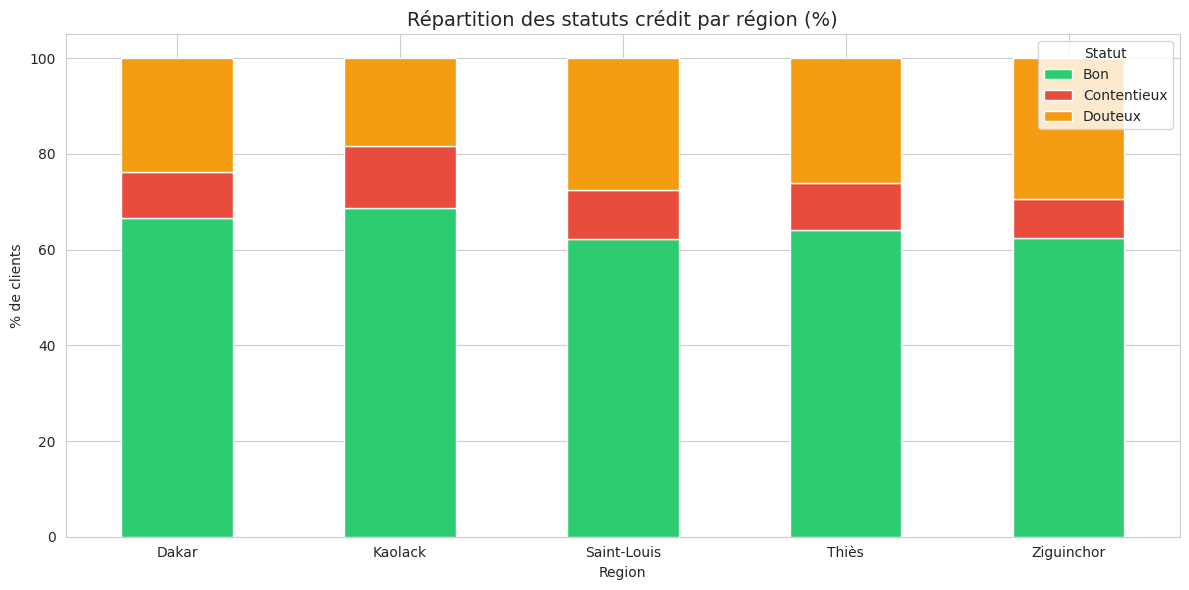

In [27]:
crosstab_region = pd.crosstab(df['Region'], df['Statut_Credit'], normalize='index').round(3) * 100
print(crosstab_region)

crosstab_region.plot(kind='bar', stacked=True,
                     color=['#2ecc71', '#e74c3c', '#f39c12'],
                     figsize=(12, 6))
plt.title("Répartition des statuts crédit par région (%)", fontsize=14)
plt.ylabel("% de clients")
plt.xticks(rotation=0)
plt.legend(title='Statut')
plt.tight_layout()
plt.show()



- **Kaolack** : risque le plus grave (taux Contentieux 13 %  créances définitivement compromises)
- **Ziguinchor et Saint-Louis** : plus grand nombre de clients en difficulté (Douteux ≥ 28 %)
- **Dakar** est la région la plus saine avec 67 % de bons payeurs


### Risque par type de garantie


Statut_Credit     Bon  Contentieux  Douteux
Garantie                                   
Caution         66.00        11.70    22.30
Immobilière     61.20        10.50    28.20
Mobilière       65.80         9.40    24.80
Pas de garantie 75.00         6.20    18.80


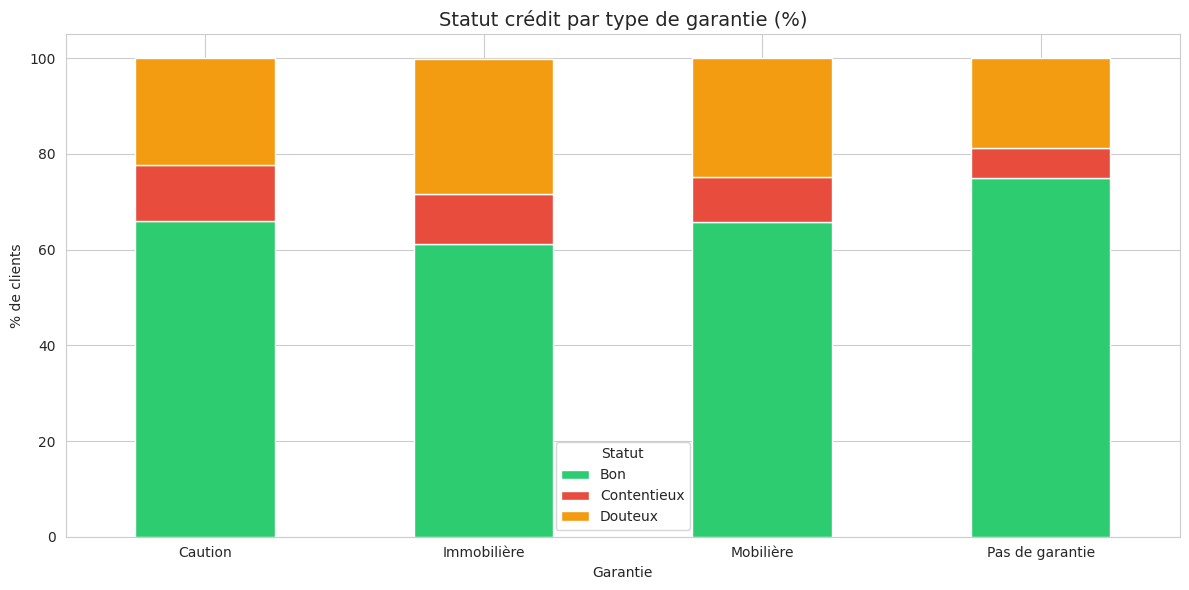

In [28]:
crosstab_garantie = pd.crosstab(df['Garantie'], df['Statut_Credit'], normalize='index').round(3) * 100
print(crosstab_garantie)

crosstab_garantie.plot(kind='bar', stacked=True,
                       color=['#2ecc71', '#e74c3c', '#f39c12'],
                       figsize=(12, 6))
plt.title("Statut crédit par type de garantie (%)", fontsize=14)
plt.ylabel("% de clients")
plt.xticks(rotation=0)
plt.legend(title='Statut')
plt.tight_layout()
plt.show()


**Résultat :** Les proportions de mauvais payeurs sont similaires quelle que soit la garantie (~9–12 % de Contentieux). La garantie seule ne protège pas suffisamment la banque. La **qualité de l'analyse de crédit** en amont reste le levier principal.


### Revenu mensuel et statut


Clients avec revenu > 500 000 FCFA par statut :
  Bon : 133 clients
  Douteux : 50 clients
  Contentieux : 12 clients


/tmp/ipykernel_16522/2465629720.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Revenu_Mensuel'] < df['Revenu_Mensuel'].quantile(0.99)],


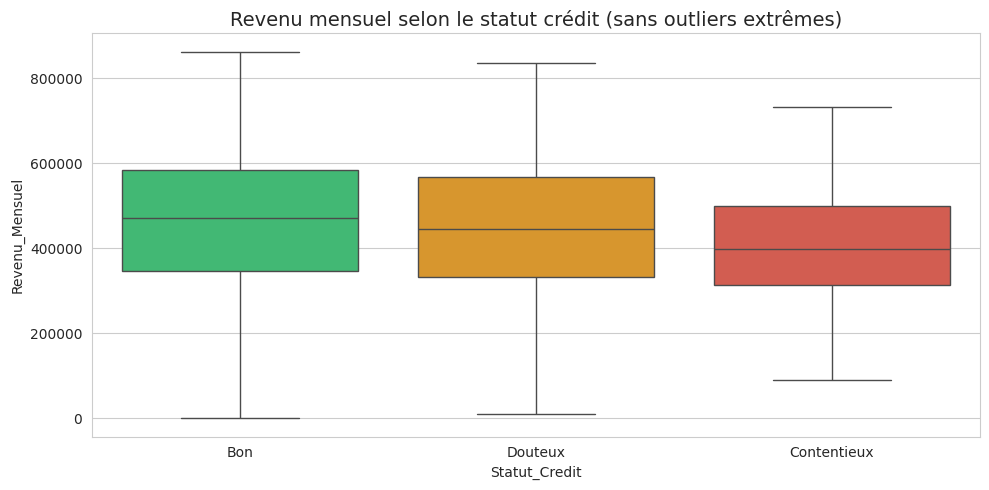

In [29]:
print("Clients avec revenu > 500 000 FCFA par statut :")
for statut in ['Bon', 'Douteux', 'Contentieux']:
    n = df[(df['Statut_Credit'] == statut) & (df['Revenu_Mensuel'] > 500_000)].shape[0]
    print(f"  {statut} : {n} clients")

# Boxplot revenu par statut
sns.boxplot(data=df[df['Revenu_Mensuel'] < df['Revenu_Mensuel'].quantile(0.99)],
            x='Statut_Credit', y='Revenu_Mensuel',
            order=['Bon', 'Douteux', 'Contentieux'],
            palette={'Bon':'#2ecc71', 'Douteux':'#f39c12', 'Contentieux':'#e74c3c'})
plt.title("Revenu mensuel selon le statut crédit (sans outliers extrêmes)", fontsize=14)
plt.tight_layout()
plt.show()


Un revenu élevé (> 500 000 FCFA) ne garantit pas un bon remboursement :
- 135 clients "Bon" ont un revenu > 500 000 FCFA
- Mais **50 clients "Douteux"** et **12 clients "Contentieux"** aussi

Cela confirme que **le revenu seul n'est pas suffisant** pour évaluer le risque. La combinaison (revenu / montant / retard) est plus pertinente.


### Durée du crédit et statut


In [30]:
crosstab_duree = pd.crosstab(df['Duree_Mois'], df['Statut_Credit'])
print(crosstab_duree)


Statut_Credit  Bon  Contentieux  Douteux
Duree_Mois                              
12              69           10       25
24              48           11       25
36              69           11       26
48              63           10       24
60              75            8       26


**Résultat :** La durée du crédit **ne joue pas de rôle significatif** sur le statut : on retrouve des bons et mauvais payeurs à toutes les durées (12, 24, 36, 48, 60 mois). Ce n'est pas un facteur discriminant en lui-même.


## L'exploitabilité des données ?

### Synthèse de la qualité des données


In [31]:
# Récapitulatif final
print("=== ÉTAT DU DATASET APRÈS NETTOYAGE ===")
print(f"Lignes        : {df.shape[0]}")
print(f"Colonnes      : {df.shape[1]}")
print()
print("Valeurs manquantes restantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Anomalies identifiées :")
print(f"  - Retard > 360 jours : {df['anomalie_retard'].sum()} client(s)")
print(f"  - Revenus négatifs corrigés : 4")
print(f"  - Crédit incohérent (>80M / revenu faible) : 1")


=== ÉTAT DU DATASET APRÈS NETTOYAGE ===
Lignes        : 500
Colonnes      : 12

Valeurs manquantes restantes :
Revenu_Mensuel    20
Taux_Interet      10
dtype: int64

Anomalies identifiées :
  - Retard > 360 jours : 1 client(s)
  - Revenus négatifs corrigés : 4
  - Crédit incohérent (>80M / revenu faible) : 1
